In [22]:
import matplotlib.pyplot as plt
import graph_style as gs
gs.set_graph_style(1)


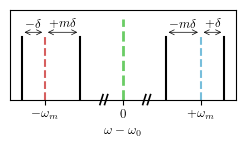

In [45]:

m = 1.0
d = 0.3
r = 1.5

fig_width = gs.get_fig_width()/2
fig_height = fig_width/2.5
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Central line
ax.axvline(0, ymin=0, ymax=0.9, linewidth=2, color=gs.get_color(1))

# Lines at ±m
ym = 0.7
ax.axvline(+m, linestyle="--", linewidth=1.5, ymax=ym, color=gs.get_color(5))
ax.axvline(-m, linestyle="--", linewidth=1.5, ymax=ym, color=gs.get_color(2))

# Lines at m ± d
yd = 0.7
ax.axvline(+m+d, linestyle="-", linewidth=1.5, ymax=yd, color="black")
ax.axvline(+m-r*d, linestyle="-", linewidth=1.5, ymax=yd, color="black")

# Lines at -m ± d
ax.axvline(-m+r*d, linestyle="-", linewidth=1.5, ymax=yd, color="black")
ax.axvline(-m-d, linestyle="-", linewidth=1.5, ymax=yd, color="black")

# Arrows showing the ±d spacings
y_arrow = 1.8

arrows = [
    (-m - d, -m, r"$-\delta$"),
    (-m, -m + r*d, r"$+m\delta$"),
    ( m - r*d,  m, r"$-m\delta$"),
    ( m,      m + d, r"$+\delta$"),
]

for x1, x2, label in arrows:
    ax.annotate(
        "",
        xy=(x2, y_arrow),
        xytext=(x1, y_arrow),
        arrowprops=dict(
            arrowstyle="<->",
            linewidth=0.5
        )
    )

    ax.text(
        (x1 + x2) / 2,
        y_arrow + 0.05,
        label,
        ha="center",
        va="bottom"
    )
# Position of decorative axis break
xbreak = (m - r*d) / 2
xbreak2 = (-m + r*d) / 2
xbreaks = [xbreak, xbreak2]

# Size of the // symbol
dx = 0.02
dy = 0.055

# Two diagonal strokes
for xbreak in xbreaks:
    ax.plot(
        [xbreak - dx, xbreak + dx],
        [-dy, +dy],
        transform=ax.get_xaxis_transform(),
        color="k",
        clip_on=False,
        linewidth=1.2,
        linestyle="-"
    )

    ax.plot(
        [xbreak + 2*dx, xbreak + 4*dx],
        [-dy, +dy],
        transform=ax.get_xaxis_transform(),
        color="k",
        clip_on=False,
        linewidth=1.2,
        linestyle="-"
    )

ax.set_ylim(0, 1.25) 

ax.set_xlim(-m - r*d, m + r*d)
ax.set_xticks([-m, 0, m])
ax.set_xticklabels(["$-\\omega_m$",  0,  "$+\\omega_m$"])
ax.set_ylim(0, 2.4)

ax.set_yticks([])
ax.set_xlabel("$\\omega-\\omega_0$")
ax.grid(False)

f_name = "..\\..\\pdf_figure\\ch6\\four-tones.pdf"
plt.savefig(f_name, bbox_inches="tight", pad_inches=0.05)
